<a href="https://colab.research.google.com/github/fathimapb/Employee_Attrition/blob/main/Employee_Attrition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**AI-Based Employee Attrition Prediction Syste**m

Problem statement
In today’s competitive business environment, employee retention has become a critical challenge for organizations. High employee attrition leads to increased recruitment and training costs, loss of experienced talent, decreased productivity, and disruption in organizational performance. Despite this, many companies still rely on reactive approaches, addressing attrition only after employees resign.

Human Resource (HR) departments often struggle to identify employees who are at risk of leaving due to:

Lack of data-driven tools to monitor employee satisfaction and engagement
Difficulty in analyzing multiple factors such as workload, salary, work-life balance, and career growth
Inability to detect early warning signs of dissatisfaction

As a result, organizations face:

Unexpected employee turnover
Increased operational costs
Reduced team efficiency and morale
Loss of valuable organizational knowledge

To address this issue, there is a need for an intelligent system that can analyze employee data proactively and identify individuals who are likely to leave the organization.

This project proposes an AI-based employee attrition prediction system that uses historical HR data, including employee demographics, job role, salary, performance metrics, and workplace satisfaction indicators, to predict the likelihood of employee turnover.

By applying machine learning techniques, the system can uncover hidden patterns and relationships that contribute to attrition.

The solution aims to:

Enable early identification of at-risk employees
Assist HR teams in data-driven decision making
Support employee retention strategies
Improve overall organizational productivity and stability

This system can act as a decision-support tool for HR professionals, helping organizations shift from reactive hiring strategies to proactive employee retention planning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/employee_attrition_dataset.csv")
df.head()

,age,gender,department,job_role,monthly_income,work_experience,job_satisfaction,work_life_balance,overtime,performance_rating,attrition
0,58,Female,Sales,Clerk,73710,12,Low,Poor,No,3,0
1,48,Male,IT,Engineer,108797,26,Low,Poor,No,4,0
2,34,Male,Sales,Engineer,84061,17,Medium,Average,No,3,0
3,27,Female,HR,Manager,48791,33,Low,Average,Yes,5,1
4,40,Male,Sales,Manager,142480,28,Medium,Average,No,4,0


In [ ]:
df.tail()

,age,gender,department,job_role,monthly_income,work_experience,job_satisfaction,work_life_balance,overtime,performance_rating,attrition
119995,48,Male,HR,Manager,127297,33,Low,Average,Yes,4,1
119996,45,Female,IT,Executive,106747,32,Medium,Average,Yes,5,0
119997,51,Female,IT,Clerk,40416,10,Low,Average,No,4,0
119998,46,Male,Finance,Clerk,90463,20,Medium,Average,No,4,0
119999,30,Female,Sales,Executive,139720,18,Medium,Average,Yes,3,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   age                 120000 non-null  int64 
 1   gender              120000 non-null  object
 2   department          120000 non-null  object
 3   job_role            120000 non-null  object
 4   monthly_income      120000 non-null  int64 
 5   work_experience     120000 non-null  int64 
 6   job_satisfaction    120000 non-null  object
 7   work_life_balance   120000 non-null  object
 8   overtime            120000 non-null  object
 9   performance_rating  120000 non-null  int64 
 10  attrition           120000 non-null  int64 
dtypes: int64(5), object(6)
memory usage: 10.1+ MB


In [ ]:
df.isnull().sum()

,0
age,0
gender,0
department,0
job_role,0
monthly_income,0
work_experience,0
job_satisfaction,0
work_life_balance,0
overtime,0
performance_rating,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(120000, 11)

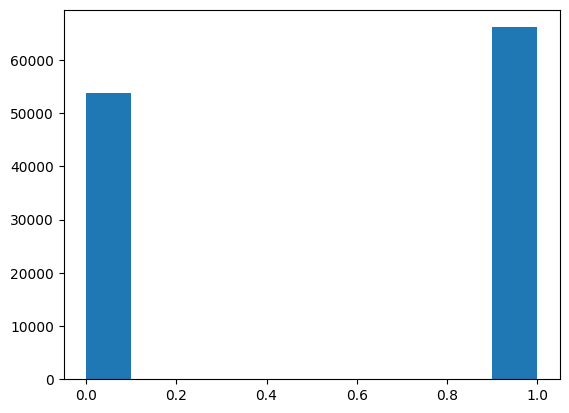

In [ ]:
plt.hist(df["attrition"])
plt.show()

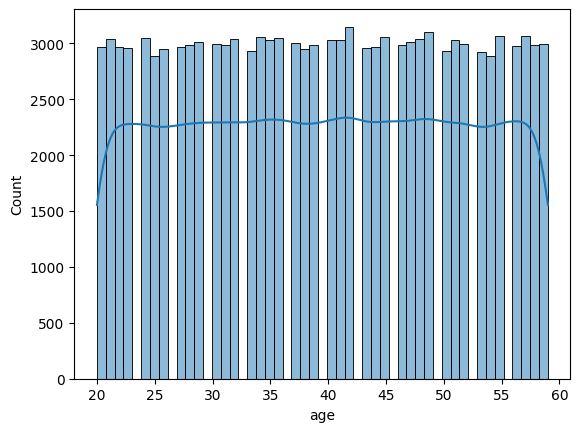

In [ ]:
sns.histplot(df['age'], kde=True)
plt.show()

In [ ]:
df.head()

,age,gender,department,job_role,monthly_income,work_experience,job_satisfaction,work_life_balance,overtime,performance_rating,attrition
0,58,Female,Sales,Clerk,73710,12,Low,Poor,No,3,0
1,48,Male,IT,Engineer,108797,26,Low,Poor,No,4,0
2,34,Male,Sales,Engineer,84061,17,Medium,Average,No,3,0
3,27,Female,HR,Manager,48791,33,Low,Average,Yes,5,1
4,40,Male,Sales,Manager,142480,28,Medium,Average,No,4,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   age                 120000 non-null  int64 
 1   gender              120000 non-null  object
 2   department          120000 non-null  object
 3   job_role            120000 non-null  object
 4   monthly_income      120000 non-null  int64 
 5   work_experience     120000 non-null  int64 
 6   job_satisfaction    120000 non-null  object
 7   work_life_balance   120000 non-null  object
 8   overtime            120000 non-null  object
 9   performance_rating  120000 non-null  int64 
 10  attrition           120000 non-null  int64 
dtypes: int64(5), object(6)
memory usage: 10.1+ MB


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()



df['gender'] = le.fit_transform(df['gender'])
df['department'] = le.fit_transform(df['department'])
df['job_role'] = le.fit_transform(df['job_role'])
df['overtime'] = le.fit_transform(df['overtime'])


In [ ]:
print(df["work_life_balance"].unique())

['Poor' 'Average' 'Good']


In [ ]:
df["job_satisfaction"].replace(['Low', 'Medium', 'High'],[1,2,3],inplace=True)

/tmp/ipykernel_15861/2361771989.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["job_satisfaction"].replace(['Low', 'Medium', 'High'],[1,2,3],inplace=True)
/tmp/ipykernel_15861/2361771989.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["job_satisfaction"].replace(['Low', 'Medium', 'Hig

In [ ]:
df["work_life_balance"].replace(['Poor', 'Average', 'Good'],[1,2,3],inplace=True)

/tmp/ipykernel_15861/639581433.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["work_life_balance"].replace(['Poor', 'Average', 'Good'],[1,2,3],inplace=True)
/tmp/ipykernel_15861/639581433.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["work_life_balance"].replace(['Poor', 'Average', 

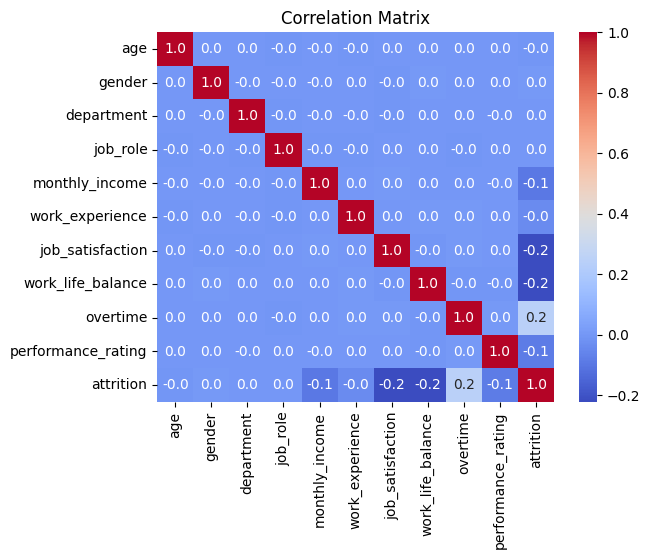

In [ ]:
corr_matrix = df.corr()

sns.heatmap(corr_matrix,annot=True, fmt='0.01f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

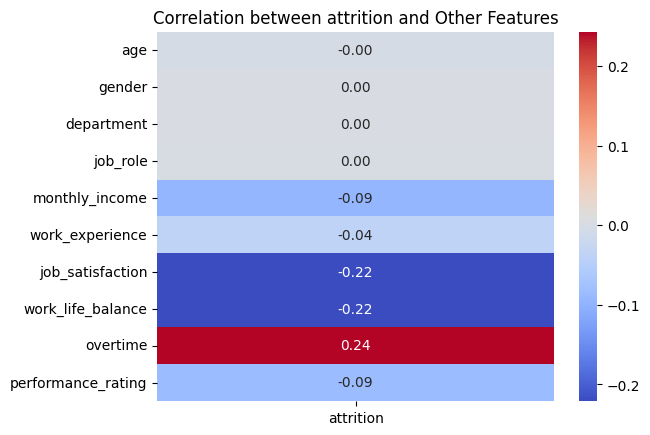

In [ ]:
survived_corr = df.corr()['attrition']

survived_corr = survived_corr.drop('attrition')

sns.heatmap(survived_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})
plt.title('Correlation between attrition and Other Features')
plt.show()

In [ ]:
df.drop(["age","gender","department",'job_role','work_experience'],axis=1,inplace=True)

<Axes: >

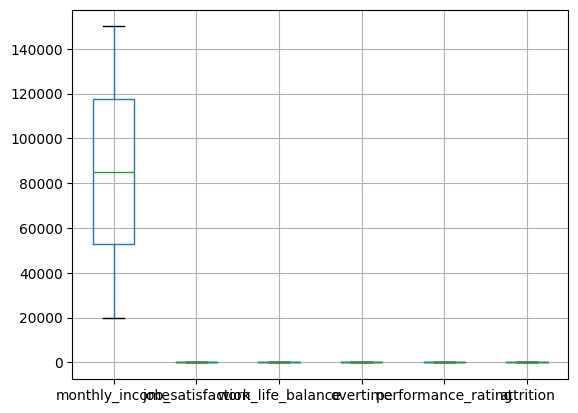

In [ ]:
df.boxplot()

In [ ]:
def remove_outliers_iqr(df, exclude_column):
    for col in df.columns:
        if col == exclude_column:
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

df_cleaned = remove_outliers_iqr(df, exclude_column='attrition')
df=df_cleaned

In [ ]:
df.shape

(120000, 6)

In [ ]:
df.head()

,monthly_income,job_satisfaction,work_life_balance,overtime,performance_rating,attrition
0,73710,1,1,0,3,0
1,108797,1,1,0,4,0
2,84061,2,2,0,3,0
3,48791,1,2,1,5,1
4,142480,2,2,0,4,0


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler



features = ['monthly_income','job_satisfaction','work_life_balance',"overtime","performance_rating"]

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[features])

scaled_df = pd.DataFrame(scaled_data, columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd


X = df[['monthly_income','job_satisfaction','work_life_balance',"overtime","performance_rating"]]
y = df['attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.68


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd


X = df[['monthly_income','job_satisfaction','work_life_balance',"overtime","performance_rating"]]
y = df['attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.59


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Features and target
X = df[['monthly_income','job_satisfaction','work_life_balance',"overtime","performance_rating"]]
y = df['attrition']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Pipeline with scaling + LinearSVC
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearSVC(random_state=42, max_iter=10000))
])

# Train
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f'LinearSVC with scaling accuracy: {accuracy:.2f}')

LinearSVC with scaling accuracy: 0.68


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd


X = df[['monthly_income','job_satisfaction', 'work_life_balance',"overtime","performance_rating"]]
y = df['attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.59


In [ ]:
model=LogisticRegression()
model.fit(X_train,y_train)
model.score(X_test,y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.6816

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(X_train,y_train)
model.score(X_test,y_test)

0.5933666666666667

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(X_train,y_train)
model.score(X_test,y_test)

0.5949

In [ ]:
from keras import preprocessing
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_classification



In [ ]:
model=Sequential()
model.add(Dense(128,input_shape=(5,),activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(X_train,y_train,epochs=80,batch_size=32)

Epoch 1/80
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.5514 - loss: 0.6879
Epoch 2/80
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5514 - loss: 0.6879
Epoch 3/80
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.5514 - loss: 0.6879
Epoch 4/80
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5514 - loss: 0.6879
Epoch 5/80
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.5514 - loss: 0.6879
Epoch 6/80
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5514 - loss: 0.6879
Epoch 7/80
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.5514 - loss: 0.6879
Epoch 8/80
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.5514 - loss: 0.6879
Epoch 9/80
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.5514 - loss: 0.6879
Epoch 10/80
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5514 - loss: 0.6879
Epoch 11/80
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.5514 - loss: 0.6879
Epoch 12/80
2813/2813 ━━━━━━━

In [ ]:
probs=model.predict(np.expand_dims(X_test.iloc[0],axis=0))

pred_classes=np.round(probs).astype(int)

print("Probabilities:\n",probs.flatten())
print()
print("Predicted classes (by rounding):",pred_classes.flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Probabilities:
 [0.55340374]

Predicted classes (by rounding): [1]


In [ ]:
loss,accuracy=model.evaluate(X_test,y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5505 - loss: 0.6880
Model Accuracy: 55.05%


**Conclusion**

The AI-Based Employee Attrition Prediction System was successfully developed to identify employees who are likely to leave an organization based on demographic, job-related, and workplace satisfaction factors. The problem was formulated as a binary classification task, where the model predicts whether an employee will stay (0) or leave (1).

Among the models evaluated, Logistic Regression achieved the best performance with an accuracy of 68.16%. This indicates that the model is capable of capturing general trends and relationships between variables such as salary, job satisfaction, work-life balance, and employee attrition. However, the overall predictive performance is moderate, suggesting that the model does not fully capture the complexity of employee behavior.

The results highlight that:

 -Employee attrition is influenced by a combination of organizational, behavioral, and personal factors
 -Linear models like Logistic Regression can identify basic patterns, but may fail to capture complex relationships
 -The current dataset provides useful insights, but may lack deeper behavioral or psychological features

Despite its limitations, the system can still be used as a support tool for HR departments to identify employees who may be at risk of leaving, enabling early intervention strategies such as improving job satisfaction, adjusting workload, or offering incentives.

Insights

 -Factors like job satisfaction, work-life balance, and overtime likely have strong influence
 -Attrition is not purely linear → involves complex interactions
 -Moderate accuracy suggests hidden patterns not fully captured

Limitations

 -Accuracy (~68%) is not sufficient for critical decision-making alone
 -Possible class imbalance affecting results
 -Logistic Regression may be too simple for this problem
 -Limited feature engineering

Future Scope

To improve the system:

 -Use advanced models:
   -Random Forest
   -Gradient Boosting (XGBoost, LightGBM)
 -Perform feature engineering (e.g., satisfaction index, workload ratios)
 -Apply hyperparameter tuning
 -Handle class imbalance (SMOTE, class weights)
 -Evaluate with:
   -Precision, Recall, F1-score
   -ROC-AUC Curve
 -Use cross-validation

Final Verdict

The project demonstrates that machine learning can assist in predicting employee attrition, but achieving high accuracy requires better feature representation, model tuning, and possibly more advanced algorithms. The current system provides a solid foundation for building a more reliable HR decision-support tool.